# PROBLEM STATEMENT 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings ('ignore')



In [2]:
df = pd.read_csv("ai4i2020.csv")
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# STEP 1 : Basic Understanding 

In [3]:
df.shape

(10000, 14)

In [4]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


# STEP 2 : Check Missing Values

In [6]:
df.isnull().sum()


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

# STEP 3 :Drop Unnecessary Columns

In [7]:
df.drop(['UDI','Product ID'], axis=1, inplace=True)


In [8]:


# Drop failure type columns to prevent data leakage
df.drop(['TWF','HDF','PWF','OSF','RNF'], axis=1, inplace=True)


# STEP 4 : Understanding about the Target distribution 

In [9]:
df['Machine failure'].value_counts()


Machine failure
0    9661
1     339
Name: count, dtype: int64

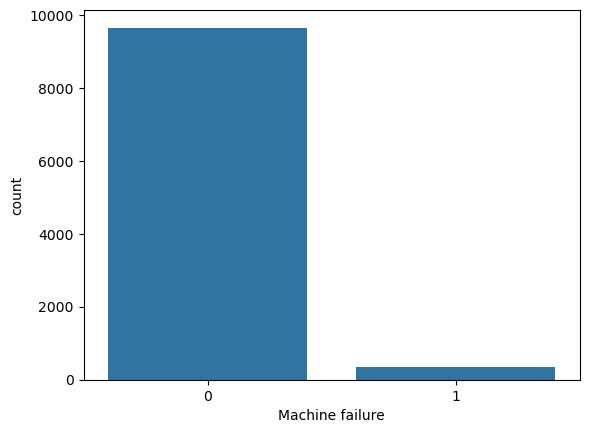

In [10]:
sns.countplot(x='Machine failure', data=df)
plt.show()


### Inference

# STEP 5 :  Correlation Matrix

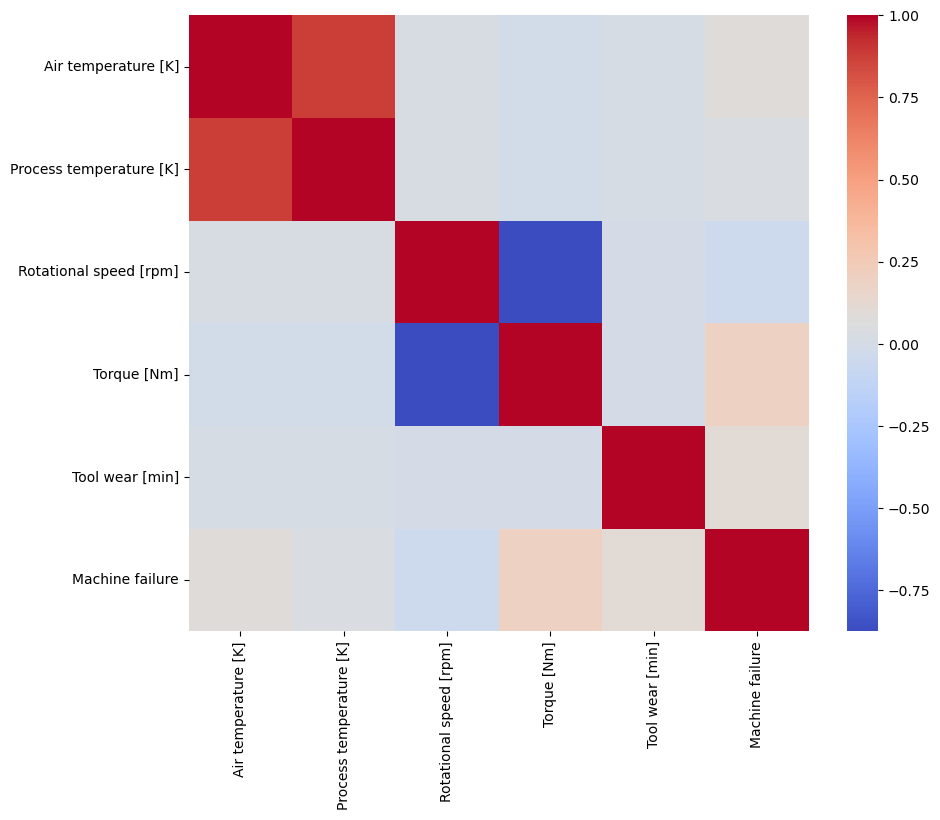

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.show()



# STEP 6: Feature vs Target Analysis

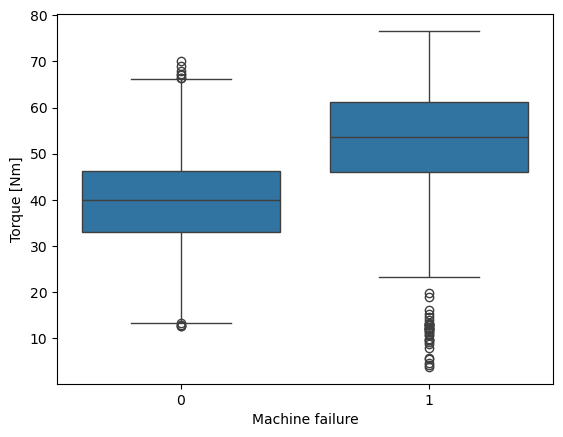

In [12]:
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df)
plt.show()


# STEP 7: Create Temperature Difference Feature

In [13]:
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']


In [14]:
df['Temp_diff']

0       10.5
1       10.5
2       10.4
3       10.4
4       10.5
        ... 
9995     9.6
9996     9.5
9997     9.6
9998     9.7
9999     9.7
Name: Temp_diff, Length: 10000, dtype: float64

# STEP 8 : Encode Categorical Column

In [15]:
df = pd.get_dummies(df, columns=['Type'], drop_first=True)


In [16]:
df['Type_L'] = df['Type_L'].astype(int)
df['Type_M'] = df['Type_M'].astype(int)


In [17]:
df

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_diff,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,10.5,0,1
1,298.2,308.7,1408,46.3,3,0,10.5,1,0
2,298.1,308.5,1498,49.4,5,0,10.4,1,0
3,298.2,308.6,1433,39.5,7,0,10.4,1,0
4,298.2,308.7,1408,40.0,9,0,10.5,1,0
...,...,...,...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,0,9.6,0,1
9996,298.9,308.4,1632,31.8,17,0,9.5,0,0
9997,299.0,308.6,1645,33.4,22,0,9.6,0,1
9998,299.0,308.7,1408,48.5,25,0,9.7,0,0


# STEP 9 :  Define Features & Target

In [18]:
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']


# STEP 10 : Train Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


# STEP 11:  Feature Scaling (for Logistic Regression)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## MODEL BUILDING 

### MODEL 1 Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


[[1596  336]
 [  12   56]]
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.83      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.83      0.88      2000



### Model 2: Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [24]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


[[1925    7]
 [  22   46]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.87      0.68      0.76        68

    accuracy                           0.99      2000
   macro avg       0.93      0.84      0.88      2000
weighted avg       0.98      0.99      0.98      2000



# STEP 12 : Model Comparison

In [25]:
from sklearn.metrics import recall_score

recall_lr = recall_score(y_test, y_pred_lr)
recall_rf = recall_score(y_test, y_pred_rf)

print("Logistic Recall:", recall_lr)
print("Random Forest Recall:", recall_rf)


Logistic Recall: 0.8235294117647058
Random Forest Recall: 0.6764705882352942


# STEP 13 : Feature Importance

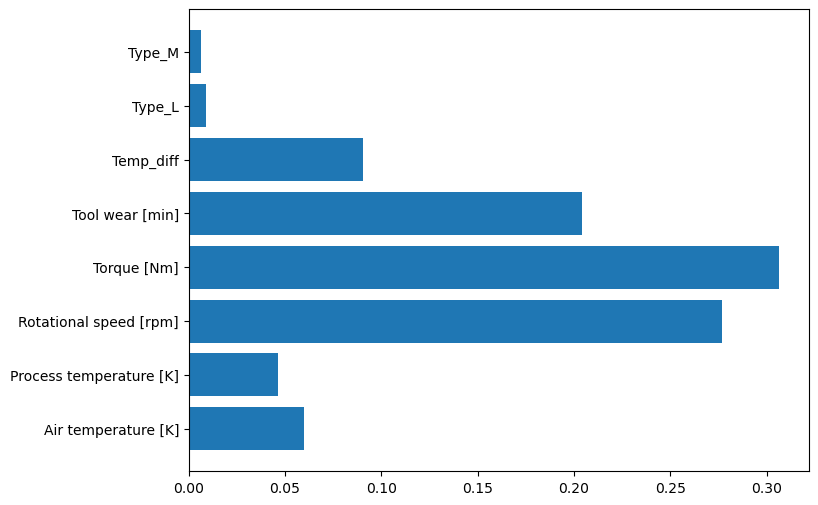

In [26]:


importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,6))
plt.barh(features, importances)
plt.show()


# STEP 14 : ROC Curve

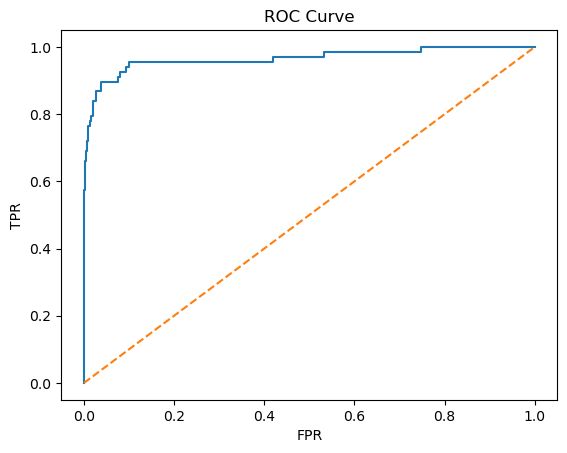

AUC: 0.9654579222993546


In [27]:
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))


In [28]:
import joblib

joblib.dump(rf, "machine_failure_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

### Inference:

# FINAL CONCLUSION: